In [7]:


# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


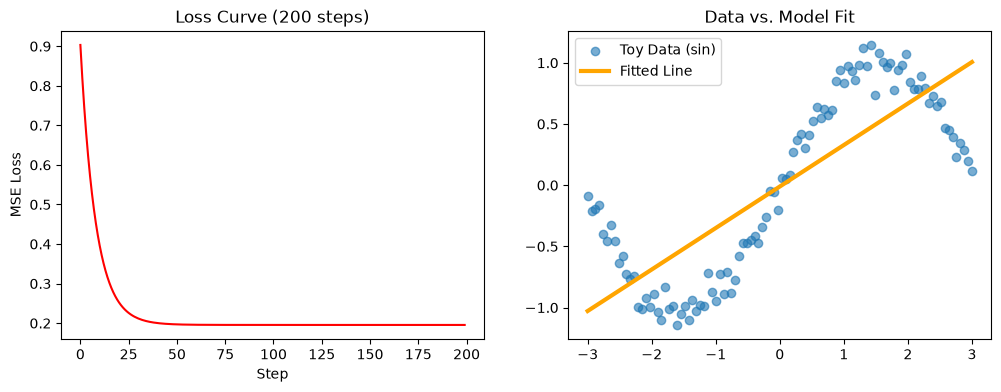

In [ ]:
## Part 1.1

# 1. Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# 2. Initialise w and b to small random values
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
lr = 0.01
losses = []

# 3. Implement ONE gradient-descent step by hand, looped
for i in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)
    
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    
    w -= lr * dw
    b -= lr * db

# 4. Plot the loss curve and the fitted line
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, color='red')
ax1.set_title("Loss Curve (200 steps)")
ax1.set_xlabel("Step")
ax1.set_ylabel("MSE Loss")

ax2.scatter(x, y, label="Toy Data (sin)", alpha=0.6)
ax2.plot(x, w * x + b, color='orange', linewidth=3, label="Fitted Line")
ax2.set_title("Data vs. Model Fit")
ax2.legend()

plt.show()

![LossFuncDerivative](
    LossFunction_Derivative.png)

2. There is severe underfitting. A single neuron with no activation function calculates a purely linear combination. Mathematically, a straight line can never capture the periodic, non-linear carvature of a sine wave, regardless of how many epochs you train it for. 